In [1]:
# ==========================================================
# PID1 - Import Required Libraries
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import VarianceThreshold
from sklearn.feature_selection import mutual_info_classif

from sklearn.ensemble import RandomForestClassifier

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [2]:
# ==========================================================
# PID2 - Load Training & Testing Data
# ==========================================================

output_path = "C:/Users/kalya/NTCC/NHANES/CVD_ML_python/Outputs/"

X_train = pd.read_csv(output_path + "X_train.csv")

X_test = pd.read_csv(output_path + "X_test.csv")

y_train = pd.read_csv(
    output_path + "y_train.csv"
).squeeze()

y_test = pd.read_csv(
    output_path + "y_test.csv"
).squeeze()

print("Training :", X_train.shape)

print("Testing  :", X_test.shape)

Training : (12365, 642)
Testing  : (3092, 642)


In [3]:
# ==========================================================
# PID3 - Remove Constant Features (Variance Threshold)
# ==========================================================

vt = VarianceThreshold(threshold=0)

vt.fit(X_train)

selected_features = X_train.columns[vt.get_support()]

removed_features = X_train.columns[~vt.get_support()]

X_train = X_train[selected_features]
X_test = X_test[selected_features]

print("="*60)
print("VARIANCE THRESHOLD REPORT")
print("="*60)

print(f"Original Features : {len(selected_features)+len(removed_features)}")
print(f"Selected Features : {len(selected_features)}")
print(f"Removed Features  : {len(removed_features)}")

VARIANCE THRESHOLD REPORT
Original Features : 642
Selected Features : 638
Removed Features  : 4


In [4]:
# ==========================================================
# Apply Variance Threshold to Training and Testing Sets
# ==========================================================

X_train = X_train[selected_features]
X_test = X_test[selected_features]

print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

Training Shape : (12365, 638)
Testing Shape  : (3092, 638)


In [5]:
# ==========================================================
# PID4 - Remove Non-Predictive Variables
# ==========================================================

remove_columns = [

    "SEQN",
    "SDMVPSU",
    "SDMVSTRA",
    "WTINTPRP",
    "WTMECPRP"

]

remove_columns = [
    col for col in remove_columns
    if col in X_train.columns
]

X_train = X_train.drop(columns=remove_columns)

X_test = X_test.drop(columns=remove_columns)

print("="*60)
print("NON-PREDICTIVE VARIABLES REMOVED")
print("="*60)

print(remove_columns)

print("\nTraining :", X_train.shape)

print("Testing  :", X_test.shape)

NON-PREDICTIVE VARIABLES REMOVED
['SEQN', 'SDMVPSU', 'SDMVSTRA', 'WTINTPRP', 'WTMECPRP']

Training : (12365, 633)
Testing  : (3092, 633)


In [6]:
# ==========================================================
# PID5 - Identify Continuous Variables
# ==========================================================

continuous_features = [
    col
    for col in X_train.columns
    if X_train[col].dtype in ["int64","float64"]
    and X_train[col].nunique() > 10
]

print("="*60)
print("CONTINUOUS VARIABLES")
print("="*60)

print("Count :", len(continuous_features))

print("\nFirst 20 Variables")

print(continuous_features[:20])

CONTINUOUS VARIABLES
Count : 236

First 20 Variables
['RIDAGEYR', 'INDFMPIR', 'BPXOSY1', 'BPXOSY2', 'BPXOSY3', 'BPXODI1', 'BPXODI2', 'BPXODI3', 'LBXGLU', 'LBXGH', 'LBXIN', 'LBXTC', 'LBDLDL', 'LBDHDD', 'LBXTR', 'BMXWT', 'BMXHT', 'BMXBMI', 'BMXWAIST', 'BMXHIP']


In [7]:
# ==========================================================
# PID6 - Correlation Matrix
# ==========================================================

corr_matrix = X_train[continuous_features].corr(method="pearson")

print("CORRELATION MATRIX")

print(f"Shape : {corr_matrix.shape}")

CORRELATION MATRIX
Shape : (236, 236)


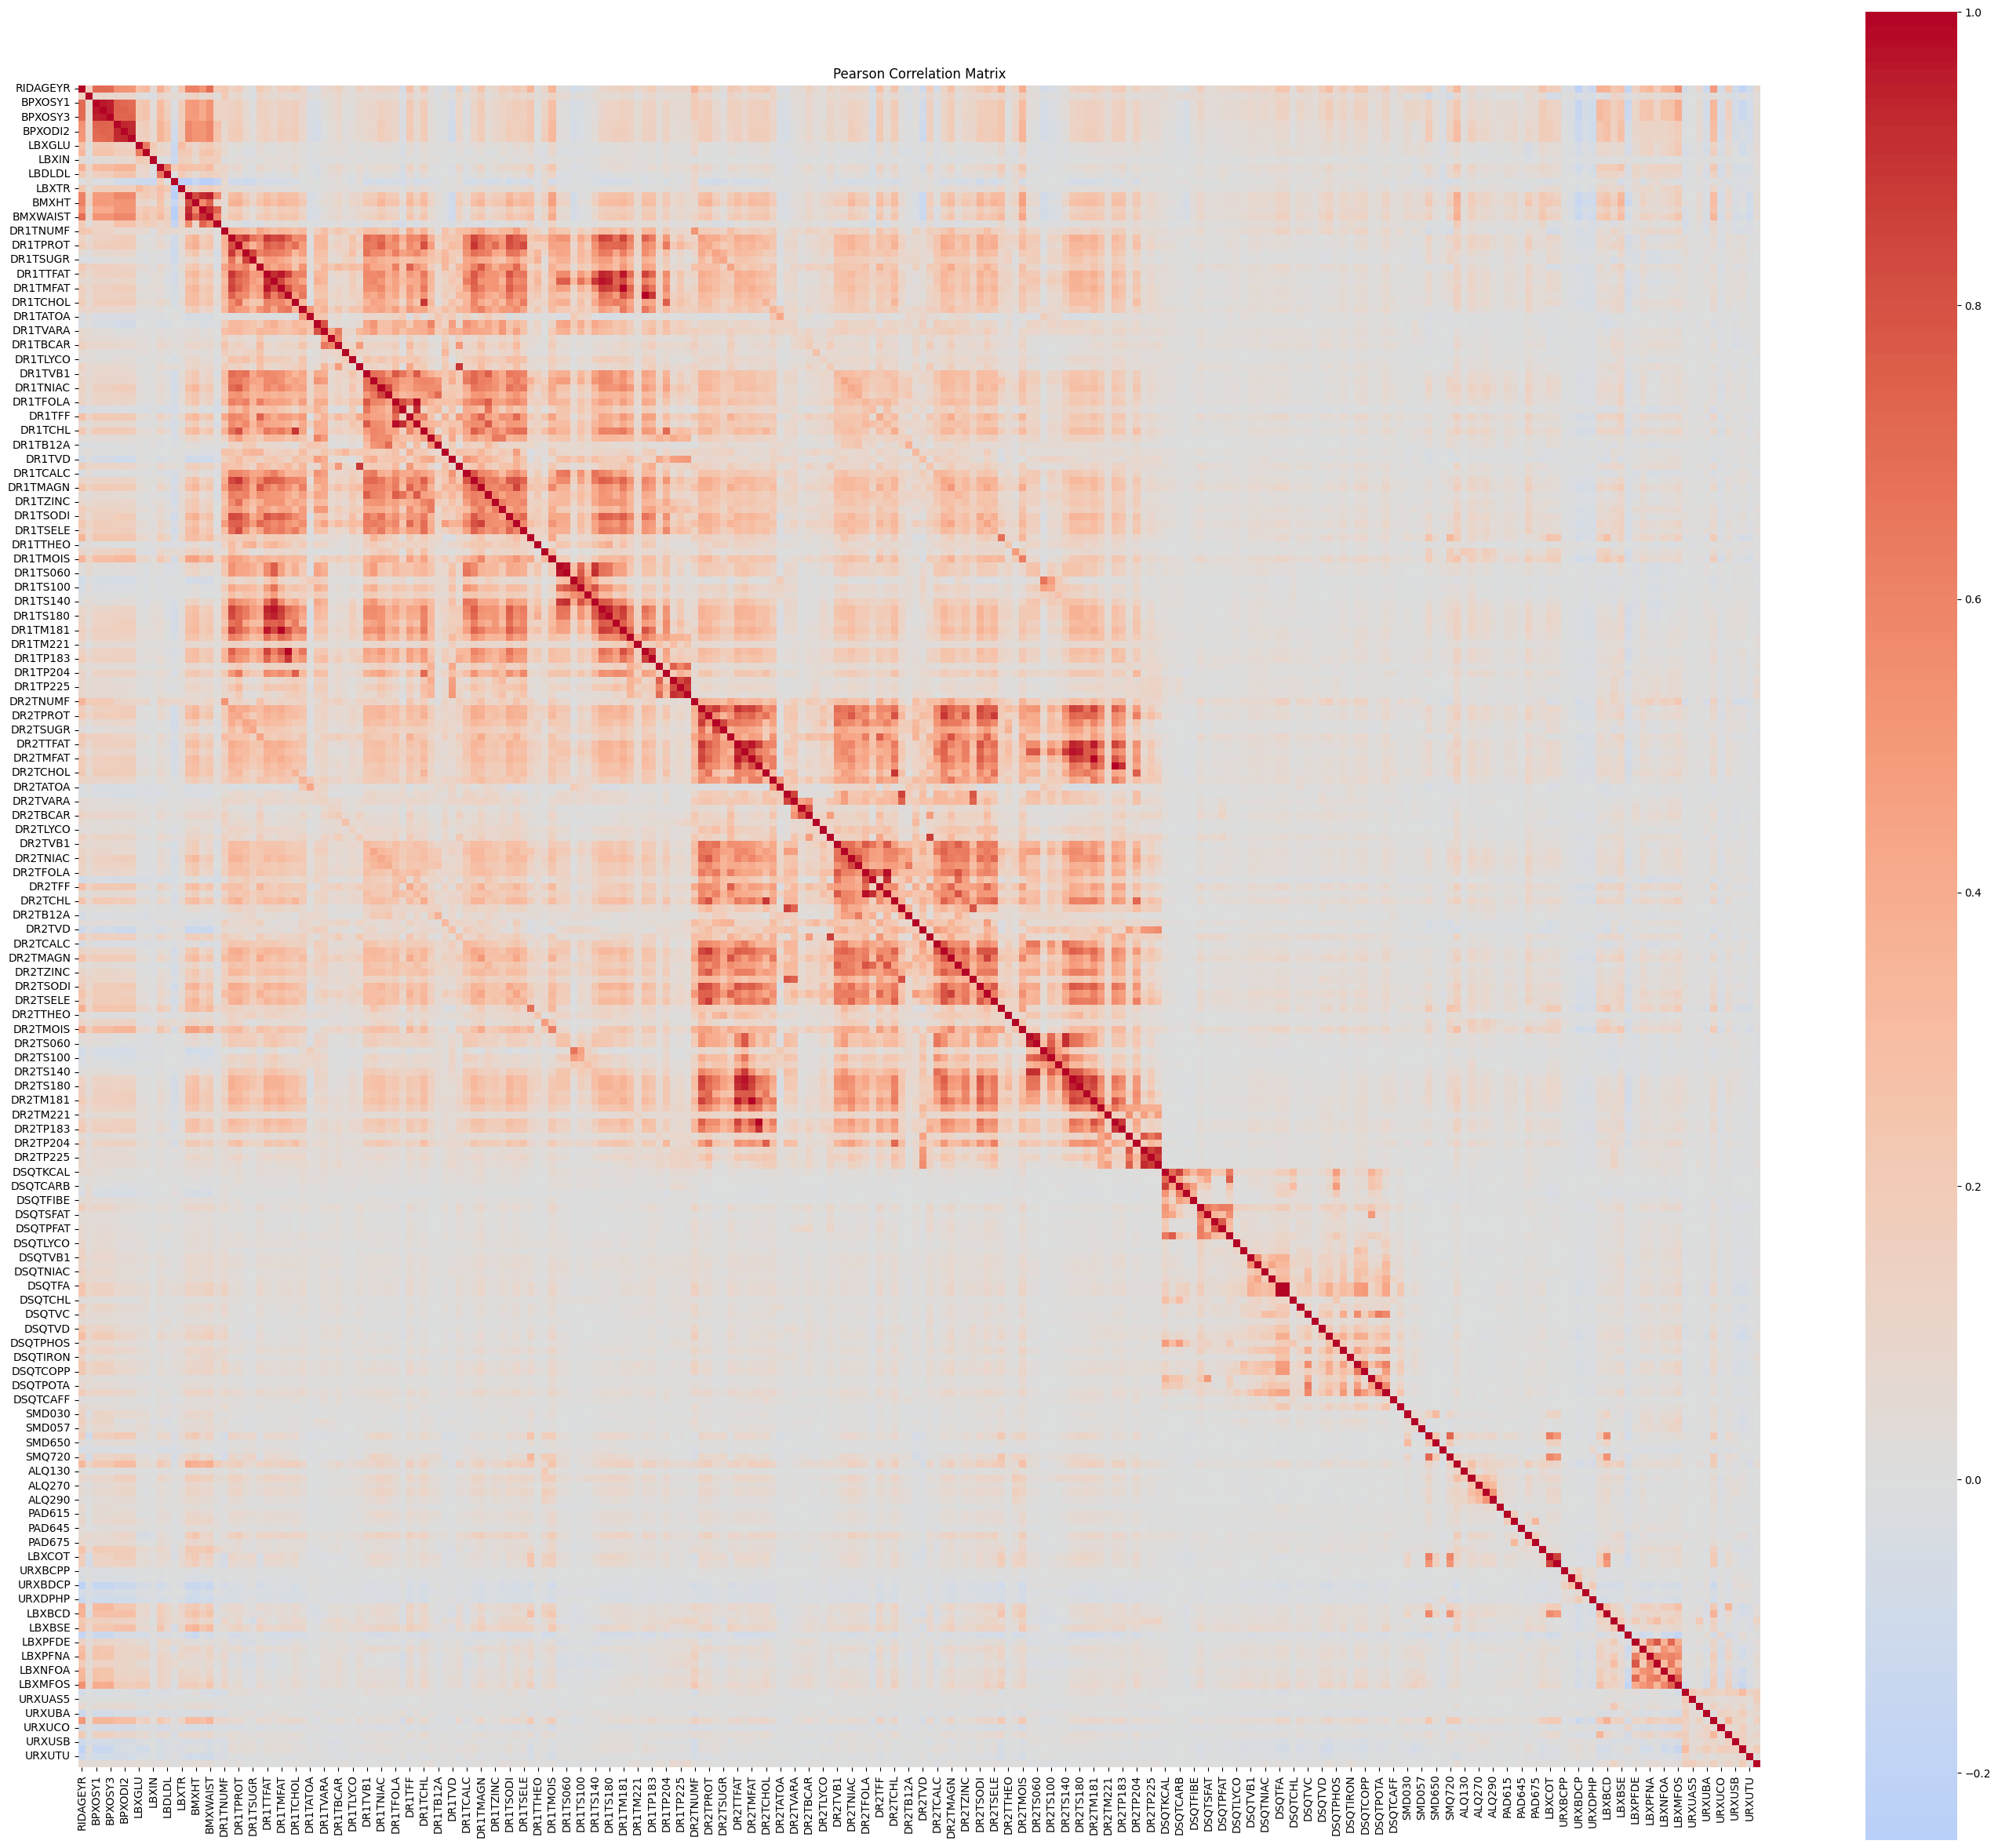

In [8]:
# Correlation Matrix
plt.figure(figsize=(28,24))

sns.heatmap(

    corr_matrix,

    cmap="coolwarm",

    center=0,

    square=True,

    linewidths=0

)

plt.title("Pearson Correlation Matrix")

plt.tight_layout()

plt.show()

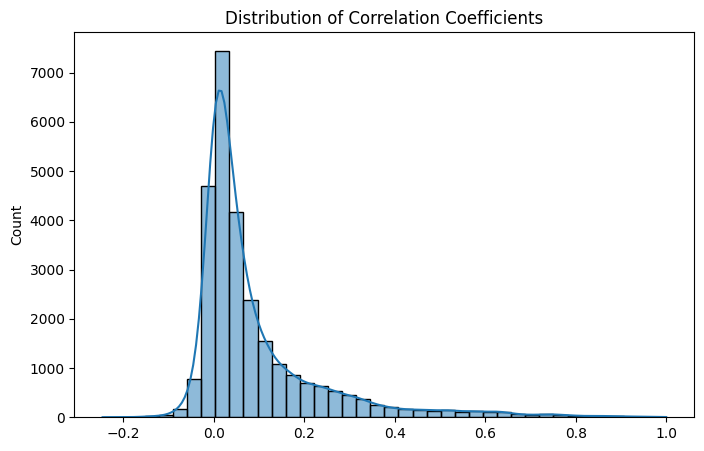

In [9]:
# Heatmap
corr_values = corr_matrix.where(

    np.triu(np.ones(corr_matrix.shape),k=1).astype(bool)

).stack()

plt.figure(figsize=(8,5))

sns.histplot(

    corr_values,

    bins=40,

    kde=True

)

plt.title("Distribution of Correlation Coefficients")

plt.show()

In [10]:
# Correlation Distribution
correlation_threshold = 0.95
high_corr_pairs = []

for i in range(len(corr_matrix.columns)):

    for j in range(i):

        corr_value = corr_matrix.iloc[i,j]

        if abs(corr_value) > correlation_threshold:

            high_corr_pairs.append({

                "Feature_1":corr_matrix.columns[i],

                "Feature_2":corr_matrix.columns[j],

                "Correlation":corr_value

            })

high_corr_df = pd.DataFrame(high_corr_pairs)

print("="*60)
print("HIGHLY CORRELATED FEATURE PAIRS")

print("="*60)
print(high_corr_df.head(20))

HIGHLY CORRELATED FEATURE PAIRS
   Feature_1 Feature_2  Correlation
0    BPXOSY2   BPXOSY1     0.961406
1    BPXOSY3   BPXOSY1     0.951211
2    BPXOSY3   BPXOSY2     0.959405
3   DR1TMFAT  DR1TTFAT     0.964479
4   DR1TFDFE  DR1TFOLA     0.978878
5   DR1TS060  DR1TS040     0.961431
6   DR1TS160  DR1TSFAT     0.968914
7   DR1TS180  DR1TSFAT     0.950151
8   DR1TM181  DR1TTFAT     0.963484
9   DR1TM181  DR1TMFAT     0.998959
10  DR1TP182  DR1TPFAT     0.997538
11  DR2TMFAT  DR2TTFAT     0.962825
12  DR2TFDFE  DR2TFOLA     0.978512
13  DR2TS160  DR2TSFAT     0.973456
14  DR2TS180  DR2TSFAT     0.955292
15  DR2TM181  DR2TTFAT     0.960502
16  DR2TM181  DR2TMFAT     0.999001
17  DR2TP182  DR2TPFAT     0.997658
18  DSQTFDFE    DSQTFA     1.000000


In [11]:
# ==========================================================
# PID7 - Remove Missing Indicator Variables
# ==========================================================

missing_indicator_columns = [

    col

    for col in X_train.columns

    if col.endswith("_WASMISSING")

]

X_train = X_train.drop(columns=missing_indicator_columns)

X_test = X_test.drop(columns=missing_indicator_columns)

print("="*60)

print("MISSING INDICATOR VARIABLES REMOVED")

print("="*60)

print(len(missing_indicator_columns))

MISSING INDICATOR VARIABLES REMOVED
317


In [12]:
# ==========================================================
# PID8 - Remove Selected Highly Correlated Variables
# ==========================================================

correlated_features_to_remove = [

    "DR1TM181",
    "DR1TP182",
    "DR1TFOLA",
    "DR2TM181",
    "DR2TP182",
    "DR2TFOLA",
    "DSQTFA"

]

correlated_features_to_remove = [

    col

    for col in correlated_features_to_remove

    if col in X_train.columns

]

X_train = X_train.drop(columns=correlated_features_to_remove)

X_test = X_test.drop(columns=correlated_features_to_remove)

print("="*60)

print("HIGHLY CORRELATED VARIABLES REMOVED")

print("="*60)

print(correlated_features_to_remove)

HIGHLY CORRELATED VARIABLES REMOVED
['DR1TM181', 'DR1TP182', 'DR1TFOLA', 'DR2TM181', 'DR2TP182', 'DR2TFOLA', 'DSQTFA']


In [13]:
# ==========================================================
# PID9 - Random Forest Feature Importance
# ==========================================================

rf = RandomForestClassifier(

    n_estimators=500,

    random_state=42,

    n_jobs=-1,

    class_weight="balanced"

)

rf.fit(X_train,y_train)

rf_importance = pd.DataFrame({

    "Feature":X_train.columns,

    "Importance":rf.feature_importances_

}).sort_values(

    "Importance",

    ascending=False

).reset_index(drop=True)

display(rf_importance.head(20))

,Feature,Importance
0,RIDAGEYR,0.059471
1,BPQ020,0.043140
2,URXUCD,0.029884
3,BPQ090D,0.029375
4,LBXGLU,0.025249
5,LBXNFOS,0.023164
6,SMQ856,0.019380
7,LBXPFNA,0.018909
8,LBXMFOS,0.018628
9,LBXNFOA,0.017901


In [14]:
# ==========================================================
# PID10 - Mutual Information
# ==========================================================

mi_scores = mutual_info_classif(

    X_train,

    y_train,

    random_state=42

)

mi_importance = pd.DataFrame({

    "Feature":X_train.columns,

    "MI_Score":mi_scores

}).sort_values(

    "MI_Score",

    ascending=False

).reset_index(drop=True)

display(mi_importance.head(20))

,Feature,MI_Score
0,RIDAGEYR,0.073145
1,URXUCD,0.063430
2,LBXNFOS,0.060985
3,LBXMFOS,0.057415
4,LBXGLU,0.054714
5,URXUPB,0.053718
6,LBXPFHS,0.052441
7,SMQ856,0.051847
8,LBXNFOA,0.051711
9,URXDPHP,0.051646


In [15]:
# ==========================================================
# PID11 - LASSO Feature Selection
# ==========================================================

lasso_pipeline = Pipeline([

    ("scaler",StandardScaler()),

    ("lasso",

     LogisticRegressionCV(

         penalty="l1",

         solver="saga",

         cv=5,

         scoring="roc_auc",

         class_weight="balanced",

         max_iter=5000,

         random_state=42,

         n_jobs=-1

     ))

])

lasso_pipeline.fit(X_train,y_train)

lasso_model = lasso_pipeline.named_steps["lasso"]

lasso_selected = pd.DataFrame({

    "Feature":X_train.columns,

    "Coefficient":lasso_model.coef_[0]

})

lasso_selected["AbsCoefficient"] = lasso_selected["Coefficient"].abs()

lasso_selected = lasso_selected[

    lasso_selected["Coefficient"]!=0

].sort_values(

    "AbsCoefficient",

    ascending=False

).reset_index(drop=True)

display(lasso_selected.head(20))

,Feature,Coefficient,AbsCoefficient
0,RIDAGEYR,1.248678,1.248678
1,SMQ856,0.400419,0.400419
2,BPQ020,-0.280133,0.280133
3,BPQ090D,-0.153514,0.153514
4,LBXTC,-0.150164,0.150164
5,LBXGH,0.101881,0.101881
6,SMQ050U,0.096301,0.096301
7,MCQ160A,-0.092854,0.092854
8,BMXWAIST,0.085595,0.085595
9,MCQ160P,-0.064125,0.064125


In [16]:
# ==========================================================
# PID12 - Consensus Feature Ranking
# ==========================================================

rf_top50 = set(
    rf_importance.head(50)["Feature"]
)
mi_top50 = set(
    mi_importance.head(50)["Feature"]
)
lasso_top = set(
    lasso_selected["Feature"]
)
all_features = sorted(
    list(
       rf_top50 |
        mi_top50 |
        lasso_top
    )
)
consensus = pd.DataFrame({
    "Feature":all_features
})
consensus["RandomForest"] = consensus["Feature"].isin(rf_top50).astype(int)
consensus["MutualInformation"] = consensus["Feature"].isin(mi_top50).astype(int)
consensus["LASSO"] = consensus["Feature"].isin(lasso_top).astype(int)
consensus["ConsensusScore"] = (
    consensus["RandomForest"]
    + consensus["MutualInformation"]
    + consensus["LASSO"]
)
consensus = consensus.sort_values(
    "ConsensusScore",
    ascending=False
).reset_index(drop=True)
display(consensus.head(30))
print("\nConsensus Score Distribution\n")
print(consensus["ConsensusScore"].value_counts().sort_index())

,Feature,RandomForest,MutualInformation,LASSO,ConsensusScore
0,BMXWT,1,1,1,3
1,BMXWAIST,1,1,1,3
2,BPQ020,1,1,1,3
3,BPQ090D,1,1,1,3
4,LBXGH,1,1,1,3
5,MCQ160A,1,1,1,3
6,PAD680,1,1,1,3
7,RIDAGEYR,1,1,1,3
8,SMQ856,1,1,1,3
9,LBXBCD,1,1,1,3



Consensus Score Distribution

ConsensusScore
1    33
2    34
3    10
Name: count, dtype: int64


In [17]:
# ==========================================================
# PID13 - Create Final Feature Set
# ==========================================================

final_features = consensus.loc[
    consensus["ConsensusScore"] >= 2,
    "Feature"
].tolist()

print("=" * 60)
print("FINAL FEATURE SET")
print("=" * 60)

print("Selected Features :", len(final_features))

print("\nFirst 20 Features")

print(final_features[:20])

FINAL FEATURE SET
Selected Features : 44

First 20 Features
['BMXWT', 'BMXWAIST', 'BPQ020', 'BPQ090D', 'LBXGH', 'MCQ160A', 'PAD680', 'RIDAGEYR', 'SMQ856', 'LBXBCD', 'BMXHT', 'BMXHIP', 'BMXBMI', 'URXUPB', 'URXUTL', 'SMQ866', 'URXBCEP', 'BPXOSY1', 'BPQ080', 'BPXOSY2']


In [18]:
# ==========================================================
# PID14 - Create Final Training Dataset
# ==========================================================

X_train_final = X_train[final_features].copy()

X_test_final = X_test[final_features].copy()

print("Training :", X_train_final.shape)

print("Testing  :", X_test_final.shape)

Training : (12365, 44)
Testing  : (3092, 44)


In [19]:
# PID15 - Verify Final Dataset

print("="*60)

print("FINAL DATASET SUMMARY")

print("="*60)
print("Training Missing :", X_train_final.isna().sum().sum())
print("Testing Missing  :", X_test_final.isna().sum().sum())

print("\n")

print("Training Target")

print(round(y_train.value_counts(normalize=True)*100,2))
print("\n")
print("Testing Target")
print(round(y_test.value_counts(normalize=True)*100,2))

FINAL DATASET SUMMARY
Training Missing : 0
Testing Missing  : 0


Training Target
Composite_CVD
0    92.71
1     7.29
Name: proportion, dtype: float64


Testing Target
Composite_CVD
0    92.72
1     7.28
Name: proportion, dtype: float64


In [20]:
# ==========================================================
# PID16 - Save Final Feature Selected Dataset
# ==========================================================

X_train_final.to_csv(
    output_path + "X_train_final.csv",
    index=False
)

X_test_final.to_csv(
    output_path + "X_test_final.csv",
    index=False
)

y_train.to_frame(name="Composite_CVD").to_csv(
    output_path + "y_train_final.csv",
    index=False
)

y_test.to_frame(name="Composite_CVD").to_csv(
    output_path + "y_test_final.csv",
    index=False
)

pd.DataFrame({
    "Feature": final_features
}).to_csv(
    output_path + "Final_Selected_Features.csv",
    index=False
)

consensus.to_csv(
    output_path + "Consensus_Feature_Ranking.csv",
    index=False
)

print("="*60)
print("Feature Selection Completed Successfully")
print("="*60)

Feature Selection Completed Successfully


In [21]:
# ==========================================================
# PID17 - Final Dataset Verification
# ==========================================================

print("="*70)
print("FINAL DATASET VERIFICATION")
print("="*70)

print(f"Training Features : {X_train_final.shape}")
print(f"Testing Features  : {X_test_final.shape}")

print()

print("Training Missing Values :", X_train_final.isna().sum().sum())
print("Testing Missing Values  :", X_test_final.isna().sum().sum())

print()

print("Target Distribution")

print("\nTraining")

print(y_train.value_counts(normalize=True).round(4)*100)

print("\nTesting")

print(y_test.value_counts(normalize=True).round(4)*100)

print()

print("Number of Selected Features :", len(final_features))

FINAL DATASET VERIFICATION
Training Features : (12365, 44)
Testing Features  : (3092, 44)

Training Missing Values : 0
Testing Missing Values  : 0

Target Distribution

Training
Composite_CVD
0    92.71
1     7.29
Name: proportion, dtype: float64

Testing
Composite_CVD
0    92.72
1     7.28
Name: proportion, dtype: float64

Number of Selected Features : 44


In [22]:
# ==========================================================
# Final Selected Feature Summary
# ==========================================================

feature_summary = pd.DataFrame({
    "Feature": final_features
})

feature_summary

,Feature
0,BMXWT
1,BMXWAIST
2,BPQ020
3,BPQ090D
4,LBXGH
5,MCQ160A
6,PAD680
7,RIDAGEYR
8,SMQ856
9,LBXBCD


In [27]:
# ==========================================================
# Assign Features to Domains
# ==========================================================

def assign_domain(feature):

    if feature.startswith(("RID","RIA","DMD","IND")):
        return "Demographics"

    elif feature.startswith("BMX"):
        return "Body Measurements"

    elif feature.startswith(("BPX","BPQ")):
        return "Blood Pressure"

    elif feature.startswith(("LBX","LBD")):
        return "Laboratory"

    elif feature.startswith("DIQ"):
        return "Diabetes"

    elif feature.startswith("SMQ"):
        return "Smoking"

    elif feature.startswith("ALQ"):
        return "Alcohol"

    elif feature.startswith(("PAQ","PAD")):
        return "Physical Activity"

    elif feature.startswith("SLQ"):
        return "Sleep"

    elif feature.startswith(("DR1","DR2","DS")):
        return "Diet"

    elif feature.startswith("URX"):
        return "Environmental"

    elif feature.startswith("OCQ"):
        return "Occupation"

    elif feature.startswith("HIQ"):
        return "Health Insurance"

    elif feature.startswith("DPQ"):
        return "Depression"

    else:
        return "Other"

feature_summary["Domain"] = feature_summary["Feature"].apply(assign_domain)
feature_summary.to_csv("feature_summary.csv", index=False)
feature_summary.head()

,Feature,Domain
0,BMXWT,Body Measurements
1,BMXWAIST,Body Measurements
2,BPQ020,Blood Pressure
3,BPQ090D,Blood Pressure
4,LBXGH,Laboratory


In [24]:
# ==========================================================
# Domain-wise Feature Count
# ==========================================================

domain_count = (
    feature_summary["Domain"]
    .value_counts()
    .reset_index()
)

domain_count.columns = ["Domain","Number_of_Features"]

display(domain_count)

,Domain,Number_of_Features
0,Laboratory,15
1,Environmental,10
2,Blood Pressure,6
3,Body Measurements,5
4,Smoking,3
5,Demographics,2
6,Other,1
7,Physical Activity,1
8,Diet,1


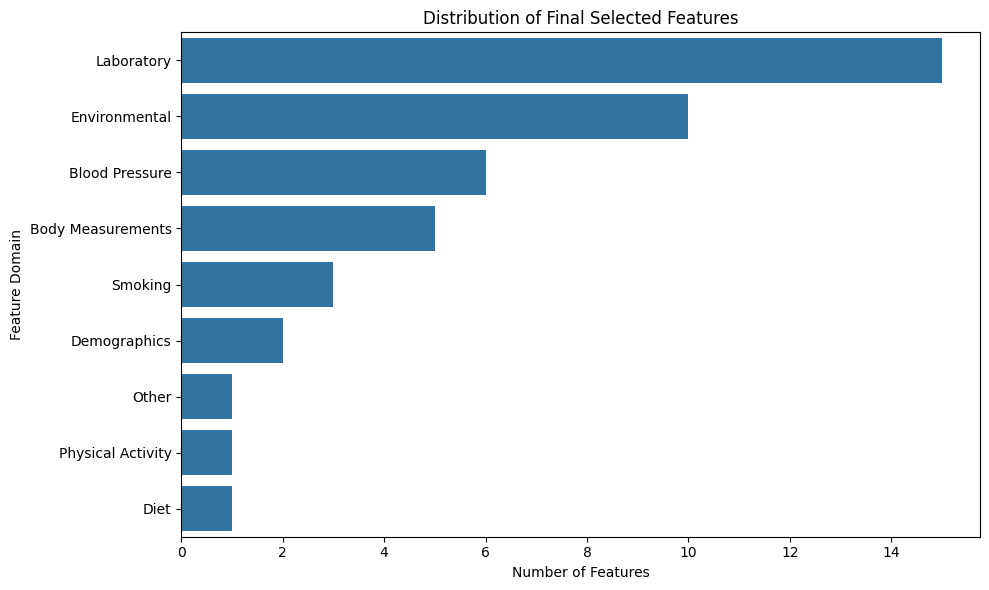

In [25]:
# ==========================================================
# Distribution of Selected Features
# ==========================================================

plt.figure(figsize=(10,6))

sns.barplot(
    data=domain_count,
    x="Number_of_Features",
    y="Domain"
)

plt.title("Distribution of Final Selected Features")

plt.xlabel("Number of Features")

plt.ylabel("Feature Domain")

plt.tight_layout()

plt.show()

In [26]:
# ==========================================================
# Save Feature Summary
# ==========================================================

feature_summary.to_csv(
    output_path + "Final_Selected_Features_Summary.csv",
    index=False
)

domain_count.to_csv(
    output_path + "Feature_Domain_Count.csv",
    index=False
)

print("Feature summary saved successfully.")

Feature summary saved successfully.
